In [22]:
# Install required geospatial libraries
!pip install rasterio geopandas numpy pandas scipy matplotlib seaborn google-cloud-storage --quiet

# Verify installation
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from google.cloud import storage

print('All libraries installed successfully')

All libraries installed successfully


In [24]:
import json

# Load bucket name from config.json (not tracked by git)
with open('config.json') as f:
    config = json.load(f)

bucket_name = config['bucket_name']
bucket = client.get_bucket(bucket_name)
blobs = list(bucket.list_blobs(prefix='UHI_Delhi/'))

print(f'Total files in bucket: {len(blobs)}')
print('\nFiles found:')
for blob in blobs:
    print(blob.name)

Total files in bucket: 33

Files found:
UHI_Delhi/Delhi_Districts.geojson
UHI_Delhi/LST_2019.tif
UHI_Delhi/LST_2020.tif
UHI_Delhi/LST_2021.tif
UHI_Delhi/LST_2022.tif
UHI_Delhi/LST_2023.tif
UHI_Delhi/LST_2024.tif
UHI_Delhi/LST_change.tif
UHI_Delhi/LST_median.tif
UHI_Delhi/NDBI_2019.tif
UHI_Delhi/NDBI_2020.tif
UHI_Delhi/NDBI_2021.tif
UHI_Delhi/NDBI_2022.tif
UHI_Delhi/NDBI_2023.tif
UHI_Delhi/NDBI_2024.tif
UHI_Delhi/NDBI_change.tif
UHI_Delhi/NDBI_median.tif
UHI_Delhi/NDVI_2019.tif
UHI_Delhi/NDVI_2020.tif
UHI_Delhi/NDVI_2021.tif
UHI_Delhi/NDVI_2022.tif
UHI_Delhi/NDVI_2023.tif
UHI_Delhi/NDVI_2024.tif
UHI_Delhi/NDVI_change.tif
UHI_Delhi/NDVI_median.tif
UHI_Delhi/results/correlation_results.json
UHI_Delhi/results/correlation_scatter_plots.png
UHI_Delhi/results/priority_sites.csv
UHI_Delhi/results/priority_sites.geojson
UHI_Delhi/results/priority_sites_map.png
UHI_Delhi/results/random_seed.json
UHI_Delhi/results/yearly_mean_statistics.csv
UHI_Delhi/results/yearly_trends.png


In [7]:
import io
import rasterio
from rasterio.io import MemoryFile
import numpy as np

def load_raster_from_gcs(bucket, filename):
    """
    Downloads a raster from GCS and loads it into memory using rasterio
    Returns the data array and the raster profile (metadata)
    """
    blob = bucket.blob(filename)
    data = blob.download_as_bytes()
    
    with MemoryFile(data) as memfile:
        with memfile.open() as dataset:
            array = dataset.read(1)  # read first band
            profile = dataset.profile
            # replace nodata values with NaN for clean analysis
            nodata = dataset.nodata
            if nodata is not None:
                array = array.astype(float)
                array[array == nodata] = np.nan
            return array, profile

# Define all years
years = [2019, 2020, 2021, 2022, 2023, 2024]

# Load all yearly rasters into dictionaries
# Keys are years, values are numpy arrays
lst_data = {}
ndvi_data = {}
ndbi_data = {}

print('Loading rasters from GCS...')

for year in years:
    print(f'Loading {year}...')
    lst_data[year], lst_profile = load_raster_from_gcs(bucket, f'UHI_Delhi/LST_{year}.tif')
    ndvi_data[year], ndvi_profile = load_raster_from_gcs(bucket, f'UHI_Delhi/NDVI_{year}.tif')
    ndbi_data[year], ndbi_profile = load_raster_from_gcs(bucket, f'UHI_Delhi/NDBI_{year}.tif')

# Load median and change detection rasters
print('Loading median and change detection rasters...')
lst_median, _ = load_raster_from_gcs(bucket, 'UHI_Delhi/LST_median.tif')
ndvi_median, _ = load_raster_from_gcs(bucket, 'UHI_Delhi/NDVI_median.tif')
ndbi_median, _ = load_raster_from_gcs(bucket, 'UHI_Delhi/NDBI_median.tif')
lst_change, _ = load_raster_from_gcs(bucket, 'UHI_Delhi/LST_change.tif')
ndvi_change, _ = load_raster_from_gcs(bucket, 'UHI_Delhi/NDVI_change.tif')
ndbi_change, _ = load_raster_from_gcs(bucket, 'UHI_Delhi/NDBI_change.tif')

print('\nAll rasters loaded successfully')
print(f'LST array shape: {lst_data[2024].shape}')
print(f'NDVI array shape: {ndvi_data[2024].shape}')
print(f'NDBI array shape: {ndbi_data[2024].shape}')

Loading rasters from GCS...
Loading 2019...
Loading 2020...
Loading 2021...
Loading 2022...
Loading 2023...
Loading 2024...
Loading median and change detection rasters...

All rasters loaded successfully
LST array shape: (1769, 1876)
NDVI array shape: (5303, 5625)
NDBI array shape: (5303, 5625)


In [8]:
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling

def resample_to_match(source_array, source_profile, target_shape):
    """
    Resamples source_array to match target_shape
    Uses bilinear interpolation — appropriate for continuous data like NDVI/NDBI
    """
    target_array = np.empty(target_shape, dtype=np.float32)
    
    reproject(
        source=source_array.astype(np.float32),
        destination=target_array,
        src_transform=source_profile['transform'],
        src_crs=source_profile['crs'],
        dst_transform=lst_profile['transform'],  # match LST transform
        dst_crs=lst_profile['crs'],
        resampling=Resampling.bilinear  # bilinear = smooth interpolation for continuous data
    )
    
    # Replace nodata with NaN
    target_array = target_array.astype(float)
    target_array[target_array == source_profile.get('nodata', -9999)] = np.nan
    
    return target_array

target_shape = lst_data[2024].shape  # 30m resolution — our common grid
print(f'Target shape (30m): {target_shape}')

# Resample NDVI and NDBI to match LST resolution for all years
ndvi_resampled = {}
ndbi_resampled = {}

print('Resampling NDVI and NDBI to 30m...')
for year in years:
    print(f'Resampling {year}...')
    ndvi_resampled[year] = resample_to_match(ndvi_data[year], ndvi_profile, target_shape)
    ndbi_resampled[year] = resample_to_match(ndbi_data[year], ndbi_profile, target_shape)

# Resample median and change rasters too
print('Resampling median and change rasters...')
ndvi_median_r = resample_to_match(ndvi_median, ndvi_profile, target_shape)
ndbi_median_r = resample_to_match(ndbi_median, ndbi_profile, target_shape)
ndvi_change_r = resample_to_match(ndvi_change, ndvi_profile, target_shape)
ndbi_change_r = resample_to_match(ndbi_change, ndbi_profile, target_shape)

print('\nResampling complete')
print(f'NDVI 2024 resampled shape: {ndvi_resampled[2024].shape}')
print(f'NDBI 2024 resampled shape: {ndbi_resampled[2024].shape}')

Target shape (30m): (1769, 1876)
Resampling NDVI and NDBI to 30m...
Resampling 2019...
Resampling 2020...
Resampling 2021...
Resampling 2022...
Resampling 2023...
Resampling 2024...
Resampling median and change rasters...

Resampling complete
NDVI 2024 resampled shape: (1769, 1876)
NDBI 2024 resampled shape: (1769, 1876)


In [9]:
# =====================
# Build Clean Pixel Dataset
# =====================
# Flatten all 2D arrays into 1D for statistical analysis
# Remove any pixel where ANY layer has NaN
# This ensures all arrays are aligned and complete

def build_pixel_dataset(year):
    """
    Takes a year and returns a clean dataframe of all valid pixels
    with LST, NDVI, NDBI values for that year
    """
    lst_flat = lst_data[year].flatten()
    ndvi_flat = ndvi_resampled[year].flatten()
    ndbi_flat = ndbi_resampled[year].flatten()
    
    df = pd.DataFrame({
        'LST': lst_flat,
        'NDVI': ndvi_flat,
        'NDBI': ndbi_flat,
        'year': year
    })
    
    # Remove rows where any value is NaN
    # These are pixels outside Delhi boundary or with no data
    df = df.dropna()
    
    return df

# Build dataset for each year
print('Building pixel datasets...')
yearly_dfs = {}
for year in years:
    yearly_dfs[year] = build_pixel_dataset(year)
    print(f'{year}: {len(yearly_dfs[year]):,} valid pixels')

# Combine all years into one master dataframe
master_df = pd.concat(yearly_dfs.values(), ignore_index=True)

# Flag COVID years
master_df['covid_year'] = master_df['year'].isin([2020, 2021])

print(f'\nTotal pixels across all years: {len(master_df):,}')
print(f'\nSample of data:')
print(master_df.head(10))
print(f'\nBasic statistics:')
print(master_df.groupby('year')[['LST', 'NDVI', 'NDBI']].mean().round(3))

Building pixel datasets...
2019: 1,904,716 valid pixels
2020: 1,904,716 valid pixels
2021: 1,904,716 valid pixels
2022: 1,904,716 valid pixels
2023: 1,904,716 valid pixels
2024: 1,904,716 valid pixels

Total pixels across all years: 11,428,296

Sample of data:
         LST      NDVI      NDBI  year  covid_year
0  44.047346  0.168391  0.075168  2019       False
1  44.026838  0.204083  0.058103  2019       False
2  45.281251  0.164695  0.122581  2019       False
3  44.467763  0.177539  0.086346  2019       False
4  44.707024  0.193129  0.082688  2019       False
5  45.575201  0.194773  0.094291  2019       False
6  47.236359  0.128426  0.129206  2019       False
7  46.692894  0.166099  0.115904  2019       False
8  45.858897  0.159161  0.130490  2019       False
9  45.858897  0.168305  0.104426  2019       False

Basic statistics:
         LST   NDVI   NDBI
year                      
2019  46.266  0.246  0.036
2020  43.739  0.256  0.030
2021  40.994  0.257  0.025
2022  42.704  0.282  0.0

In [10]:
from scipy import stats
import seaborn as sns
import os
import json

# =====================
# Statistical Analysis
# NDVI vs LST and NDBI vs LST correlation
# Using non-COVID years for primary analysis
# COVID years (2020, 2021) analyzed separately
# =====================

# Split into COVID and non-COVID datasets
non_covid_df = master_df[master_df['covid_year'] == False].copy()
covid_df = master_df[master_df['covid_year'] == True].copy()
print(f'Non-COVID pixels: {len(non_covid_df):,}')
print(f'COVID pixels: {len(covid_df):,}')

# =====================
# Sampling for Statistical Tests
# 1,904,716 pixels per year is too many for correlation tests
# Statistically, n=10,000 is more than sufficient for significance
# Seed is randomly generated and saved to GCS for reproducibility
# =====================
sample_size = 10000

# Generate random seed and save to GCS
RANDOM_SEED = int.from_bytes(os.urandom(4), 'big')
print(f'\nRandom seed used: {RANDOM_SEED}')
seed_blob = bucket.blob('UHI_Delhi/results/random_seed.json')
seed_blob.upload_from_string(json.dumps({'random_seed': RANDOM_SEED}))
print(f'Seed saved to GCS: UHI_Delhi/results/random_seed.json')

sample_df = non_covid_df.sample(n=sample_size, random_state=RANDOM_SEED)
print(f'\nSample size for correlation: {sample_size:,} pixels')
print(f'(Sampled from {len(non_covid_df):,} non-COVID pixels)')

# =====================
# Pearson Correlation — NDVI vs LST
# H0: No linear relationship between NDVI and LST
# H1: Significant negative relationship exists
# =====================
r_ndvi, p_ndvi = stats.pearsonr(sample_df['NDVI'], sample_df['LST'])
r2_ndvi = r_ndvi ** 2
print(f'\n--- NDVI vs LST ---')
print(f'Pearson r:  {r_ndvi:.4f}')
print(f'R²:         {r2_ndvi:.4f}')
print(f'p-value:    {p_ndvi:.4e}')
print(f'Significant (p<0.05): {p_ndvi < 0.05}')

# =====================
# Pearson Correlation — NDBI vs LST
# H0: No linear relationship between NDBI and LST
# H1: Significant positive relationship exists
# =====================
r_ndbi, p_ndbi = stats.pearsonr(sample_df['NDBI'], sample_df['LST'])
r2_ndbi = r_ndbi ** 2
print(f'\n--- NDBI vs LST ---')
print(f'Pearson r:  {r_ndbi:.4f}')
print(f'R²:         {r2_ndbi:.4f}')
print(f'p-value:    {p_ndbi:.4e}')
print(f'Significant (p<0.05): {p_ndbi < 0.05}')

# =====================
# Linear Regression — NDVI vs LST
# Gives us the equation: LST = intercept + slope × NDVI
# =====================
slope_ndvi, intercept_ndvi, _, _, se_ndvi = stats.linregress(
    sample_df['NDVI'], sample_df['LST']
)
print(f'\n--- Regression: LST = a + b×NDVI ---')
print(f'Intercept (a): {intercept_ndvi:.4f}')
print(f'Slope (b):     {slope_ndvi:.4f}')
print(f'Std Error:     {se_ndvi:.4f}')
print(f'Interpretation: 1 unit increase in NDVI → {slope_ndvi:.2f}°C change in LST')

# =====================
# Linear Regression — NDBI vs LST
# =====================
slope_ndbi, intercept_ndbi, _, _, se_ndbi = stats.linregress(
    sample_df['NDBI'], sample_df['LST']
)
print(f'\n--- Regression: LST = a + b×NDBI ---')
print(f'Intercept (a): {intercept_ndbi:.4f}')
print(f'Slope (b):     {slope_ndbi:.4f}')
print(f'Std Error:     {se_ndbi:.4f}')
print(f'Interpretation: 1 unit increase in NDBI → {slope_ndbi:.2f}°C change in LST')

# =====================
# COVID vs Non-COVID Comparison
# =====================
covid_sample = covid_df.sample(n=sample_size, random_state=RANDOM_SEED)
r_covid, p_covid = stats.pearsonr(covid_sample['NDVI'], covid_sample['LST'])
print(f'\n--- COVID Years NDVI vs LST ---')
print(f'Pearson r: {r_covid:.4f}')
print(f'p-value:   {p_covid:.4e}')
print(f'Mean LST COVID years:     {covid_df["LST"].mean():.3f}°C')
print(f'Mean LST non-COVID years: {non_covid_df["LST"].mean():.3f}°C')
print(f'COVID cooling effect:     {non_covid_df["LST"].mean() - covid_df["LST"].mean():.3f}°C')

Non-COVID pixels: 7,618,864
COVID pixels: 3,809,432

Random seed used: 2512217677
Seed saved to GCS: UHI_Delhi/results/random_seed.json

Sample size for correlation: 10,000 pixels
(Sampled from 7,618,864 non-COVID pixels)

--- NDVI vs LST ---
Pearson r:  -0.4787
R²:         0.2291
p-value:    0.0000e+00
Significant (p<0.05): True

--- NDBI vs LST ---
Pearson r:  0.6672
R²:         0.4451
p-value:    0.0000e+00
Significant (p<0.05): True

--- Regression: LST = a + b×NDVI ---
Intercept (a): 47.6855
Slope (b):     -11.3629
Std Error:     0.2084
Interpretation: 1 unit increase in NDVI → -11.36°C change in LST

--- Regression: LST = a + b×NDBI ---
Intercept (a): 44.0415
Slope (b):     28.1851
Std Error:     0.3147
Interpretation: 1 unit increase in NDBI → 28.19°C change in LST

--- COVID Years NDVI vs LST ---
Pearson r: -0.3962
p-value:   0.0000e+00
Mean LST COVID years:     42.366°C
Mean LST non-COVID years: 44.615°C
COVID cooling effect:     2.249°C


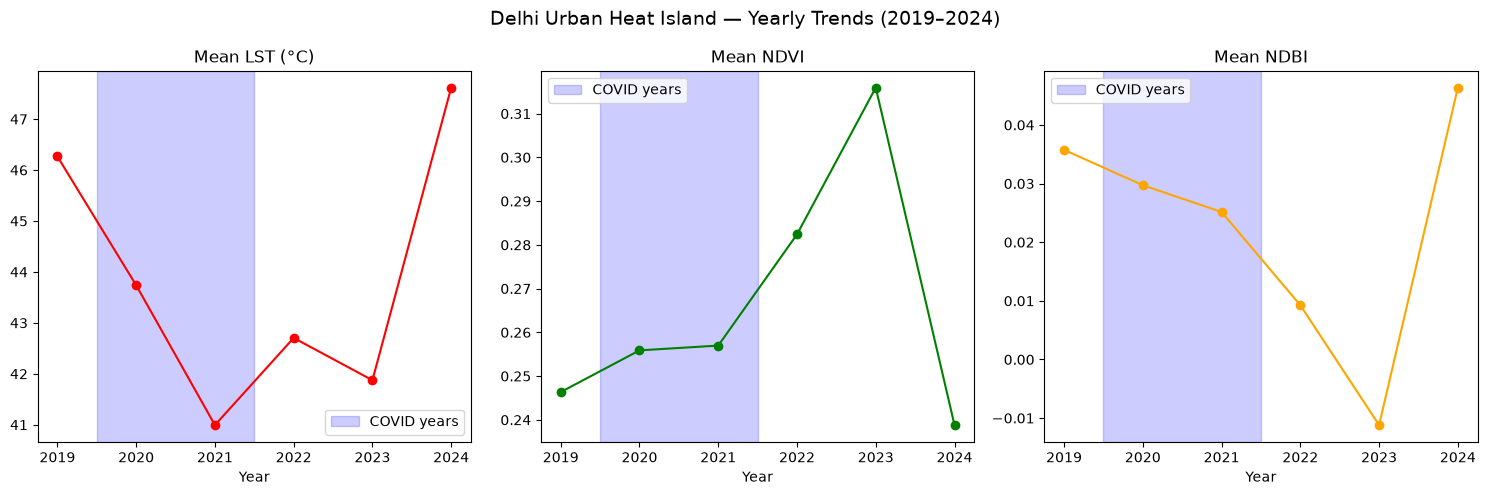

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Delhi Urban Heat Island — Yearly Trends (2019–2024)', fontsize=14)

years_list = sorted(master_df['year'].unique())
means = master_df.groupby('year')[['LST', 'NDVI', 'NDBI']].mean()

# LST trend
axes[0].plot(years_list, means['LST'], marker='o', color='red')
axes[0].axvspan(2019.5, 2021.5, alpha=0.2, color='blue', label='COVID years')
axes[0].set_title('Mean LST (°C)')
axes[0].set_xlabel('Year')
axes[0].legend()

# NDVI trend
axes[1].plot(years_list, means['NDVI'], marker='o', color='green')
axes[1].axvspan(2019.5, 2021.5, alpha=0.2, color='blue', label='COVID years')
axes[1].set_title('Mean NDVI')
axes[1].set_xlabel('Year')
axes[1].legend()

# NDBI trend
axes[2].plot(years_list, means['NDBI'], marker='o', color='orange')
axes[2].axvspan(2019.5, 2021.5, alpha=0.2, color='blue', label='COVID years')
axes[2].set_title('Mean NDBI')
axes[2].set_xlabel('Year')
axes[2].legend()

plt.tight_layout()
fig1 = plt.gcf()
plt.show()

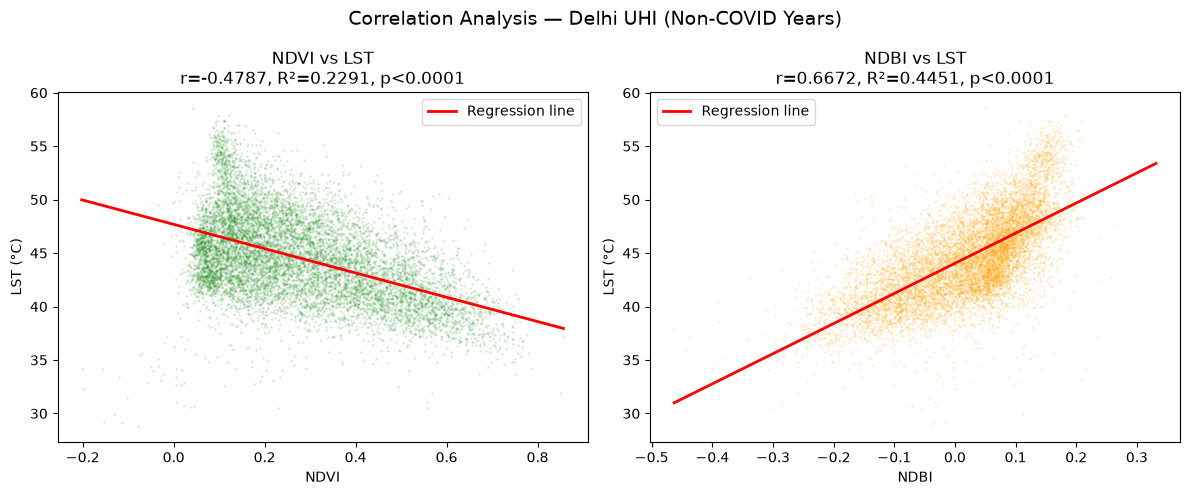

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Correlation Analysis — Delhi UHI (Non-COVID Years)', fontsize=14)

# NDVI vs LST scatter
axes[0].scatter(sample_df['NDVI'], sample_df['LST'], alpha=0.1, s=1, color='green')
# Add regression line
ndvi_line = np.linspace(sample_df['NDVI'].min(), sample_df['NDVI'].max(), 100)
axes[0].plot(ndvi_line, intercept_ndvi + slope_ndvi * ndvi_line, color='red', linewidth=2, label='Regression line')
axes[0].set_xlabel('NDVI')
axes[0].set_ylabel('LST (°C)')
axes[0].set_title(f'NDVI vs LST\nr={r_ndvi:.4f}, R²={r2_ndvi:.4f}, p<0.0001')
axes[0].legend()

# NDBI vs LST scatter
axes[1].scatter(sample_df['NDBI'], sample_df['LST'], alpha=0.1, s=1, color='orange')
# Add regression line
ndbi_line = np.linspace(sample_df['NDBI'].min(), sample_df['NDBI'].max(), 100)
axes[1].plot(ndbi_line, intercept_ndbi + slope_ndbi * ndbi_line, color='red', linewidth=2, label='Regression line')
axes[1].set_xlabel('NDBI')
axes[1].set_ylabel('LST (°C)')
axes[1].set_title(f'NDBI vs LST\nr={r_ndbi:.4f}, R²={r2_ndbi:.4f}, p<0.0001')
axes[1].legend()

plt.tight_layout()
fig2 = plt.gcf()
plt.show()

In [13]:
import io

def save_plot_to_gcs(fig, filename):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    blob = bucket.blob(f'UHI_Delhi/results/{filename}')
    blob.upload_from_file(buf, content_type='image/png')
    print(f'Saved: {filename}')

def save_json_to_gcs(data, filename):
    blob = bucket.blob(f'UHI_Delhi/results/{filename}')
    blob.upload_from_string(json.dumps(data, indent=2))
    print(f'Saved: {filename}')

def save_csv_to_gcs(df, filename):
    blob = bucket.blob(f'UHI_Delhi/results/{filename}')
    blob.upload_from_string(df.to_csv(index=True))
    print(f'Saved: {filename}')

print('Helper functions defined')

Helper functions defined


In [11]:
stats_table = master_df.groupby('year')[['LST', 'NDVI', 'NDBI']].mean().round(3)
save_csv_to_gcs(stats_table, 'yearly_mean_statistics.csv')

Saved: yearly_mean_statistics.csv


In [12]:
correlation_results = {
    'random_seed': RANDOM_SEED,
    'sample_size': sample_size,
    'non_covid_pixels': len(non_covid_df),
    'covid_pixels': len(covid_df),
    'NDVI_vs_LST': {
        'pearson_r': round(r_ndvi, 4),
        'r_squared': round(r2_ndvi, 4),
        'p_value': float(p_ndvi),
        'regression_intercept': round(intercept_ndvi, 4),
        'regression_slope': round(slope_ndvi, 4),
        'std_error': round(se_ndvi, 4)
    },
    'NDBI_vs_LST': {
        'pearson_r': round(r_ndbi, 4),
        'r_squared': round(r2_ndbi, 4),
        'p_value': float(p_ndbi),
        'regression_intercept': round(intercept_ndbi, 4),
        'regression_slope': round(slope_ndbi, 4),
        'std_error': round(se_ndbi, 4)
    },
    'COVID_analysis': {
        'pearson_r': round(r_covid, 4),
        'p_value': float(p_covid),
        'mean_lst_covid': round(covid_df['LST'].mean(), 3),
        'mean_lst_non_covid': round(non_covid_df['LST'].mean(), 3),
        'covid_cooling_effect_celsius': round(non_covid_df['LST'].mean() - covid_df['LST'].mean(), 3)
    }
}
save_json_to_gcs(correlation_results, 'correlation_results.json')

Saved: correlation_results.json


In [18]:
save_plot_to_gcs(fig1, 'yearly_trends.png')

Saved: yearly_trends.png


In [19]:
save_plot_to_gcs(fig2, 'correlation_scatter_plots.png')

Saved: correlation_scatter_plots.png


In [14]:
# =====================
# Hotspot Scoring
# Using 6-year median rasters for robust baseline
# Score = 0.4×LST + 0.3×NDBI + 0.3×(1-NDVI)
# Higher score = higher priority for Miyawaki forest
# =====================

# Flatten median rasters
lst_flat = lst_median.flatten()
ndvi_flat = ndvi_median_r.flatten()
ndbi_flat = ndbi_median_r.flatten()

# Stack into dataframe
hotspot_df = pd.DataFrame({
    'LST': lst_flat,
    'NDVI': ndvi_flat,
    'NDBI': ndbi_flat
})

# Remove NaN pixels
hotspot_df = hotspot_df.dropna()
print(f'Valid pixels for hotspot scoring: {len(hotspot_df):,}')

# Normalize to 0-1 using numpy — no sklearn needed
# Formula: (x - min) / (max - min)
def minmax_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

hotspot_df['LST_norm'] = minmax_normalize(hotspot_df['LST'])
hotspot_df['NDVI_norm'] = minmax_normalize(hotspot_df['NDVI'])
hotspot_df['NDBI_norm'] = minmax_normalize(hotspot_df['NDBI'])

# Compute hotspot score
# High LST + High NDBI + Low NDVI = high priority
hotspot_df['hotspot_score'] = (
    0.4 * hotspot_df['LST_norm'] +
    0.3 * hotspot_df['NDBI_norm'] +
    0.3 * (1 - hotspot_df['NDVI_norm'])
)

print(f'Hotspot score range: {hotspot_df["hotspot_score"].min():.4f} to {hotspot_df["hotspot_score"].max():.4f}')
print(f'\nTop 10 hotspot scores:')
print(hotspot_df.nlargest(10, 'hotspot_score'))

Valid pixels for hotspot scoring: 1,904,716
Hotspot score range: 0.0698 to 0.8709

Top 10 hotspot scores:
               LST      NDVI      NDBI  LST_norm  NDVI_norm  NDBI_norm  \
2071196  50.865442  0.078134  0.384054  0.889819   0.276909   0.993599   
2071197  50.973964  0.082323  0.379460  0.894289   0.280767   0.988533   
2071198  50.992763  0.083677  0.374594  0.895063   0.282013   0.983168   
2071195  50.805626  0.078779  0.375923  0.887356   0.277503   0.984634   
2069319  50.623617  0.075137  0.376941  0.879861   0.274150   0.985755   
2069320  50.577473  0.082250  0.366413  0.877960   0.280699   0.974148   
2257725  52.436022  0.011438  0.160156  0.954499   0.215501   0.746732   
2261477  52.541980  0.016298  0.157726  0.958863   0.219976   0.744053   
2257724  52.609486  0.023141  0.157968  0.961643   0.226277   0.744320   
2259600  52.612050  0.013043  0.148643  0.961748   0.216978   0.734039   

         hotspot_score  
2071196       0.870935  
2071197       0.870045  
2071

In [15]:
from rasterio.transform import xy

# =====================
# Convert Pixel Indices to Lat/Lon
# The index numbers (2071196 etc) are flattened array positions
# We convert them back to row/col then to lat/lon using the raster transform
# =====================

# Get top 500 candidates — we'll filter down to 10 after removing duplicates
# that are too close together (we don't want all 10 sites in the same block)
top_candidates = hotspot_df.nlargest(500, 'hotspot_score').copy()

# Get the shape of the original raster
raster_shape = lst_median.shape  # (rows, cols)

# Convert flat index to row, col
top_candidates['row'] = top_candidates.index // raster_shape[1]
top_candidates['col'] = top_candidates.index % raster_shape[1]

# Convert row, col to lon, lat using raster transform
lons, lats = xy(
    lst_profile['transform'],
    top_candidates['row'].values,
    top_candidates['col'].values
)

top_candidates['latitude'] = lats
top_candidates['longitude'] = lons

print('Top 500 hotspot candidates with coordinates:')
print(top_candidates[['LST', 'NDVI', 'NDBI', 'hotspot_score', 'latitude', 'longitude']].head(10))

Top 500 hotspot candidates with coordinates:
               LST      NDVI      NDBI  hotspot_score   latitude  longitude
2071196  50.865442  0.078134  0.384054       0.870935  28.581922  76.867267
2071197  50.973964  0.082323  0.379460       0.870045  28.581922  76.867536
2071198  50.992763  0.083677  0.374594       0.868372  28.581922  76.867806
2071195  50.805626  0.078779  0.375923       0.867082  28.581922  76.866997
2069319  50.623617  0.075137  0.376941       0.865426  28.582191  76.866997
2069320  50.577473  0.082250  0.366413       0.859219  28.582191  76.867267
2257725  52.436022  0.011438  0.160156       0.841169  28.555242  77.084210
2261477  52.541980  0.016298  0.157726       0.840768  28.554703  77.084210
2257724  52.609486  0.023141  0.157968       0.840070  28.555242  77.083940
2259600  52.612050  0.013043  0.148643       0.839817  28.554973  77.083940


In [16]:
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculates distance in km between two lat/lon points
    Used to ensure selected sites are spatially spread out
    """
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# =====================
# Select Top 10 Sites With Minimum 1.5km Spacing
# Greedy algorithm — pick highest scoring site first
# then only add next site if it's at least 1.5km from all selected sites
# =====================
min_distance_km = 1.5
selected_sites = []

for _, candidate in top_candidates.iterrows():
    too_close = False
    for site in selected_sites:
        dist = haversine_distance(
            candidate['latitude'], candidate['longitude'],
            site['latitude'], site['longitude']
        )
        if dist < min_distance_km:
            too_close = True
            break
    if not too_close:
        selected_sites.append(candidate)
    if len(selected_sites) == 10:
        break

# Convert to dataframe
final_sites = pd.DataFrame(selected_sites).reset_index(drop=True)
final_sites.index += 1  # site numbers start at 1

print(f'Final 10 priority sites:')
print(final_sites[['LST', 'NDVI', 'NDBI', 'hotspot_score', 'latitude', 'longitude']])

Final 10 priority sites:
          LST      NDVI      NDBI  hotspot_score   latitude  longitude
1   50.865442  0.078134  0.384054       0.870935  28.581922  76.867267
2   52.436022  0.011438  0.160156       0.841169  28.555242  77.084210
3   52.242049  0.004292  0.152803       0.837515  28.562518  77.120053
4   53.229857  0.103166  0.176635       0.834360  28.589198  76.890713
5   52.901727  0.167819  0.238578       0.831585  28.605368  76.892060
6   53.445192  0.120027  0.158677       0.827310  28.550661  76.875891
7   52.847893  0.100699  0.162414       0.824045  28.598092  76.875352
8   52.792350  0.087005  0.146450       0.821632  28.601056  76.906883
9   52.072857  0.087319  0.173625       0.818682  28.621807  76.944612
10  49.512760  0.041871  0.262937       0.818606  28.614261  77.244020


In [29]:
import geopandas as gpd
from shapely.geometry import Point

# Convert to GeoDataFrame
geometry = [Point(row['longitude'], row['latitude']) for _, row in final_sites.iterrows()]
gdf = gpd.GeoDataFrame(final_sites, geometry=geometry, crs='EPSG:4326')

# Add site number column
gdf['site_id'] = gdf.index
gdf['priority_rank'] = gdf.index

# Save as GeoJSON to GCS
geojson_str = gdf.to_json()
blob = bucket.blob('UHI_Delhi/results/priority_sites.geojson')
blob.upload_from_string(geojson_str, content_type='application/json')
print('Priority sites saved to GCS: UHI_Delhi/results/priority_sites.geojson')

# Also save as CSV
save_csv_to_gcs(final_sites, 'priority_sites.csv')

print('\nFinal 10 Priority Sites:')
print(gdf[['site_id', 'latitude', 'longitude', 'LST', 'NDVI', 'NDBI', 'hotspot_score']])

Priority sites saved to GCS: UHI_Delhi/results/priority_sites.geojson
Saved: priority_sites.csv

Final 10 Priority Sites:
    site_id   latitude  longitude        LST      NDVI      NDBI  \
1         1  28.581922  76.867267  50.865442  0.078134  0.384054   
2         2  28.555242  77.084210  52.436022  0.011438  0.160156   
3         3  28.562518  77.120053  52.242049  0.004292  0.152803   
4         4  28.589198  76.890713  53.229857  0.103166  0.176635   
5         5  28.605368  76.892060  52.901727  0.167819  0.238578   
6         6  28.550661  76.875891  53.445192  0.120027  0.158677   
7         7  28.598092  76.875352  52.847893  0.100699  0.162414   
8         8  28.601056  76.906883  52.792350  0.087005  0.146450   
9         9  28.621807  76.944612  52.072857  0.087319  0.173625   
10       10  28.614261  77.244020  49.512760  0.041871  0.262937   

    hotspot_score  
1        0.870935  
2        0.841169  
3        0.837515  
4        0.834360  
5        0.831585  
6        

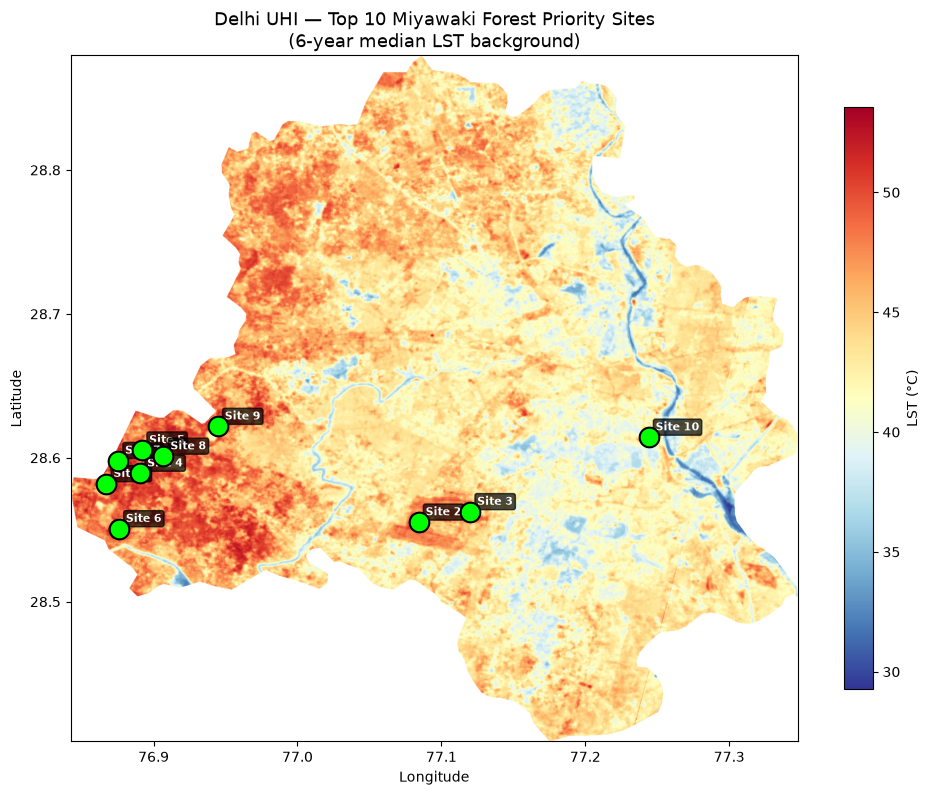

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =====================
# Plot Priority Sites on Delhi Map
# =====================
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot LST median as background heatmap
lst_plot = ax.imshow(
    lst_median,
    cmap='RdYlBu_r',
    extent=[
        lst_profile['transform'][2],  # left (min lon)
        lst_profile['transform'][2] + lst_profile['transform'][0] * lst_median.shape[1],  # right (max lon)
        lst_profile['transform'][5] + lst_profile['transform'][4] * lst_median.shape[0],  # bottom (min lat)
        lst_profile['transform'][5]   # top (max lat)
    ]
)

# Add colorbar
plt.colorbar(lst_plot, ax=ax, label='LST (°C)', shrink=0.6)

# Plot priority sites
for _, site in final_sites.iterrows():
    ax.scatter(
        site['longitude'], site['latitude'],
        s=200, color='lime', edgecolors='black',
        linewidth=1.5, zorder=5
    )
    ax.annotate(
        f"Site {int(site.name)}",
        xy=(site['longitude'], site['latitude']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=8, fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7)
    )

ax.set_title('Delhi UHI — Top 10 Miyawaki Forest Priority Sites\n(6-year median LST background)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

fig3 = plt.gcf()
plt.tight_layout()
plt.show()

In [25]:
# Load Delhi districts GeoJSON from GCS
blob = bucket.blob('UHI_Delhi/Delhi_Districts.geojson')
data = blob.download_as_bytes()
districts_gdf = gpd.read_file(io.BytesIO(data))

print(f'Districts loaded: {len(districts_gdf)}')
print(districts_gdf['DISTRICT'].values)

Districts loaded: 9
<ArrowStringArray>
[   'Central',       'East',  'New Delhi',      'North', 'North East',
 'North West',      'South', 'South West',       'West']
Length: 9, dtype: str


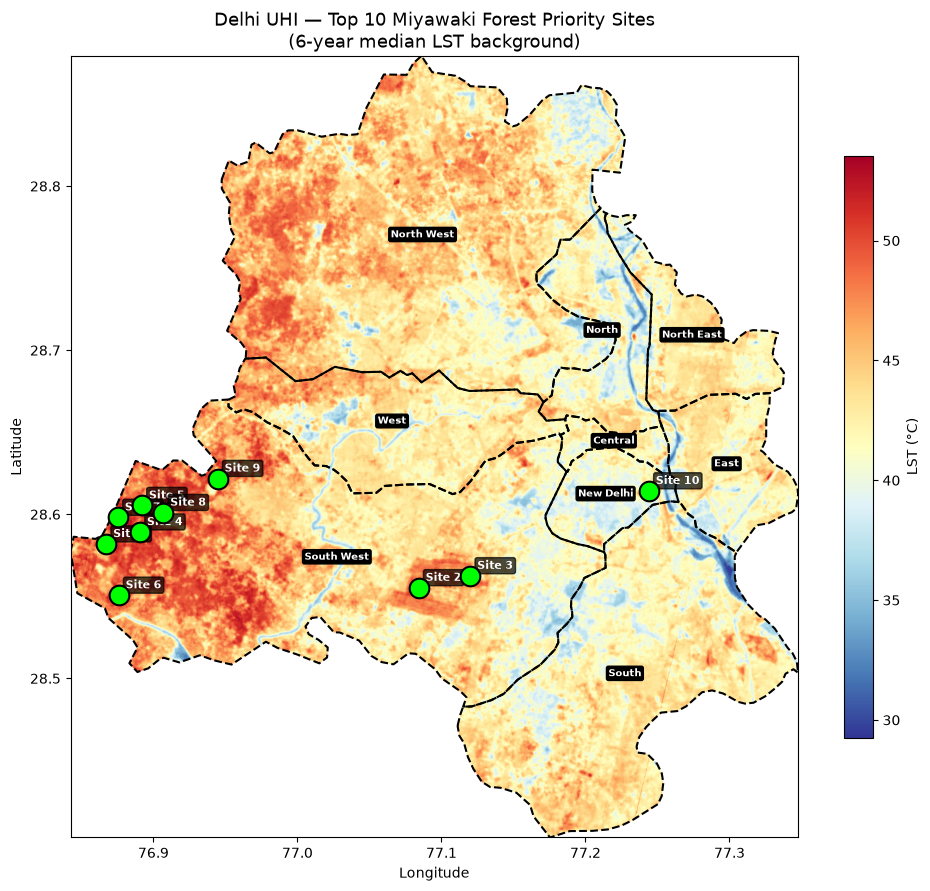

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot LST median as background heatmap
lst_plot = ax.imshow(
    lst_median,
    cmap='RdYlBu_r',
    extent=[
        lst_profile['transform'][2],
        lst_profile['transform'][2] + lst_profile['transform'][0] * lst_median.shape[1],
        lst_profile['transform'][5] + lst_profile['transform'][4] * lst_median.shape[0],
        lst_profile['transform'][5]
    ]
)

# Add colorbar
plt.colorbar(lst_plot, ax=ax, label='LST (°C)', shrink=0.6)

# Overlay district boundaries
districts_gdf.boundary.plot(
    ax=ax,
    color='black',
    linewidth=1.5,
    linestyle='--'
)

# Add district name labels
for _, row in districts_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row['DISTRICT'],
        xy=(centroid.x, centroid.y),
        fontsize=7,
        color='white',
        fontweight='bold',
        ha='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=1)
    )

# Plot priority sites
for _, site in final_sites.iterrows():
    ax.scatter(
        site['longitude'], site['latitude'],
        s=200, color='lime', edgecolors='black',
        linewidth=1.5, zorder=5
    )
    ax.annotate(
        f"Site {int(site.name)}",
        xy=(site['longitude'], site['latitude']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=8, fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7)
    )

# Clip to Delhi extent only — removes the blue line artifact
delhi_bounds = districts_gdf.total_bounds  # [minx, miny, maxx, maxy]
ax.set_xlim(delhi_bounds[0], delhi_bounds[2])
ax.set_ylim(delhi_bounds[1], delhi_bounds[3])

ax.set_title('Delhi UHI — Top 10 Miyawaki Forest Priority Sites\n(6-year median LST background)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

fig3 = plt.gcf()
plt.tight_layout()
plt.show()

In [20]:
save_plot_to_gcs(fig3, 'priority_sites_map.png')

Saved: priority_sites_map.png


In [21]:
# Download all result files from GCS to local Workbench storage
result_files = [
    'priority_sites.csv',
    'priority_sites.geojson',
    'correlation_results.json',
    'yearly_mean_statistics.csv',
    'yearly_trends.png',
    'correlation_scatter_plots.png',
    'priority_sites_map.png'
]

for filename in result_files:
    blob = bucket.blob(f'UHI_Delhi/results/{filename}')
    blob.download_to_filename(filename)
    print(f'Downloaded: {filename}')

Downloaded: priority_sites.csv
Downloaded: priority_sites.geojson
Downloaded: correlation_results.json
Downloaded: yearly_mean_statistics.csv
Downloaded: yearly_trends.png
Downloaded: correlation_scatter_plots.png
Downloaded: priority_sites_map.png
